# Introduction

We are going to use 4 different approaches and finally compare the results of all of them:
1. Min-Max normalization
2. Zero-Mean normalization
3. Crossvalidation
4. Dimensionality reduction

# Data Preparation
This [dataset](https://www.kaggle.com/datasets/rabieelkharoua/air-quality-and-health-impact-dataset) contains comprehensive information on the air quality and its impact on public health for 5,811 records. It includes variables such as air quality index (AQI), concentrations of various pollutants, weather conditions, and health impact metrics. The target variable is the health impact class, which categorizes the health impact based on the air quality and other related factors.

This dataset offers a comprehensive view of the relationship between air quality and public health, making it ideal for research, predictive modeling, and statistical analysis.

In [1]:
include("utils/utils.jl")

   Resolving package versions...
  No Changes to `C:\Users\Administrator\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\Administrator\.julia\environments\v1.10\Manifest.toml`


document (generic function with 1 method)

In [2]:
using CSV, DataFrames

# Load the dataset from the 'dataset' folder
data = CSV.read("datasets/air_quality_health_impact_data.csv", DataFrame)

# Check the dataset
describe(data)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,RecordID,2906.0,1,2906.0,5811,0,Int64
2,AQI,248.438,0.00581738,249.128,499.859,0,Float64
3,PM10,148.655,0.0158481,147.635,299.902,0,Float64
4,PM2_5,100.224,0.0315489,100.506,199.985,0,Float64
5,NO2,102.293,0.00962478,102.988,199.98,0,Float64
6,SO2,49.4568,0.0110232,49.5302,99.9696,0,Float64
7,O3,149.312,0.001661,149.56,299.937,0,Float64
8,Temperature,14.9755,-9.991,14.9424,39.9634,0,Float64
9,Humidity,54.7769,10.0015,54.5439,99.9975,0,Float64


We check how many classes have of each kind and plot the distribution

In [3]:
# Count elements in each class
counts = combine(groupby(data, :HealthImpactClass), nrow => :Count)

println("Elements per class:")
println(counts)

Elements per class:
5×2 DataFrame
 Row │ HealthImpactClass  Count 
     │ Float64            Int64 
─────┼──────────────────────────
   1 │               0.0   4808
   2 │               1.0    579
   3 │               2.0    273
   4 │               3.0     95
   5 │               4.0     56


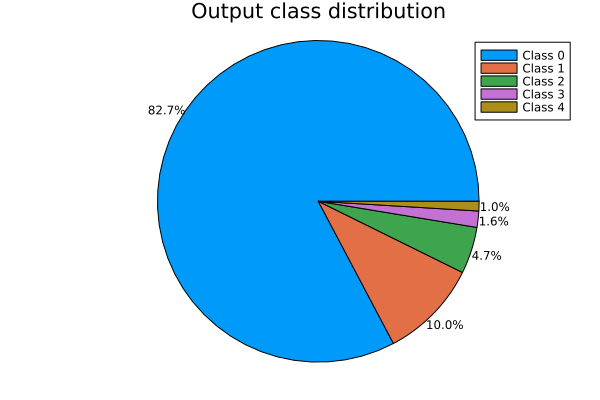

In [4]:
using Plots, Printf

cnt = counts.Count
labels = ["Class $i" for i in 0:4]
tot = sum(cnt)
datapct = [@sprintf("%.1f%%", x/tot*100) for x in cnt]

θ = (cumsum(cnt) - cnt/2) .* 360/sum(cnt)
scθ = sincosd.(θ)

p = pie(labels, cnt, title="Output class distribution")
for (s, sci) in zip(datapct, scθ)
    annotate!(1.1*sci[2], 1.1*sci[1], text(s, 8, :black))
end
p

Segmentation of the data on inputs and outputs

In [5]:
input_data = Matrix(data[!, 1:13]);
output_data = Int.(data[!, 15]);

@assert input_data isa Matrix
@assert output_data isa Vector{Int64}

To split the test from train we use the holdOut function with a fraction of 0.2. This means that 20% of the train data will be used for testing and the remaining 80% will be used for training.

In [6]:
# Split in train and test
(tr_idx, test_idx) = holdOutStratified(output_data, 0.2)

train_input = input_data[tr_idx,:]
train_output = output_data[tr_idx]
test_input = input_data[test_idx,:]
test_output = output_data[test_idx]

train_output = collect(train_output)
test_output = collect(test_output)

println("Train Input Size: ", size(train_input))
println("Train Output Size: ", size(train_output), " Categories:", sort(unique(train_output)))
println("Test Input Size: ", size(test_input))
println("Test Output Size: ", size(test_output), " Categories:", sort(unique(test_output)))

Train Input Size: (4648, 13)
Train Output Size: (4648,) Categories:[0, 1, 2, 3, 4]
Test Input Size: (1163, 13)
Test Output Size: (1163,) Categories:[0, 1, 2, 3, 4]


And we check if we have a repressentation of all the output classes in both groups (train and test)

In [7]:
columna = train_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 3846, 4 => 45, 2 => 218, 3 => 76, 1 => 463)


In [8]:
columna = test_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 962, 4 => 11, 2 => 55, 3 => 19, 1 => 116)


We will store the results of each approach in a DataFrame for easy ploting

In [9]:
metric_names = [:approach, :accuracy, :error_rate, :recall, :specificity, :ppv, :npv, :f_score]
metric_types = [String[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[]]
metrics = DataFrame(metric_types, metric_names)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


# Definition of Models and Hyperparameters

We create a dictionary to store all hyperparameters of the different models. And also another DataFrame to store the accuracies obtained in the evaluation of each model.

In [10]:
## These are the modelsHyperParameters to be used in the models training

modelsHyperParameters = [
    # ANN configurations
    Dict("estimator" => :ANN, "topology" => (64,), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_64"),
    Dict("estimator" => :ANN, "topology" => (128,), "maxEpochs" => 500, "learningRate" => 0.005, "name" => "ANN_128"),
    Dict("estimator" => :ANN, "topology" => (64, 32), "maxEpochs" => 400, "learningRate" => 0.001, "name" => "ANN_64_32"),
    Dict("estimator" => :ANN, "topology" => (128, 64), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64"),
    Dict("estimator" => :ANN, "topology" => (256,), "maxEpochs" => 300, "learningRate" => 0.05, "name" => "ANN_256"),
    Dict("estimator" => :ANN, "topology" => (128, 64, 32), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64_32"),
    Dict("estimator" => :ANN, "topology" => (64, 64), "maxEpochs" => 250, "learningRate" => 0.005, "name" => "ANN_64_64"),
    Dict("estimator" => :ANN, "topology" => (256, 128), "maxEpochs" => 200, "learningRate" => 0.001, "name" => "ANN_256_128"),

    # SVM configurations
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.5, "degree"=>2, "name" => "SVM_rbf_05"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C" => 1.0, "degree"=>4, "name" => "SVM_linear_1"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 0.01 , "degree" => 2, "name" => "SVM_poly_001"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 1.0, "degree" => 3, "name" => "SVM_sigmoid_1"),
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.01, "degree" => 3, "name" => "SVM_rbf_001"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 5, "degree" => 3, "name" => "SVM_poly_5"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C"=> 0.5, "degree" => 3, "name" => "SVM_linear_05"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 10.0, "degree" => 5, "name" => "SVM_sigmoid_10"),

    # Decision Tree configurations
    Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42, "name" => "DT_3"),
    Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42, "name" => "DT_5"),
    Dict("estimator" => :DecisionTree, "max_depth" => 7, "random_state" => 42, "name" => "DT_7"),
    Dict("estimator" => :DecisionTree, "max_depth" => 11, "random_state" => 42, "name" => "DT_11"),
    Dict("estimator" => :DecisionTree, "max_depth" => 15, "random_state" => 42, "name" => "DT_15"),
    Dict("estimator" => :DecisionTree, "max_depth" => 21, "random_state" => 42, "name" => "DT_21"),

    # kNN configurations
    Dict("estimator" => :KNN, "k" => 3, "name" => "KNN_3"),
    Dict("estimator" => :KNN, "k" => 5, "name" => "KNN_5"),
    Dict("estimator" => :KNN, "k" => 7, "name" => "KNN_7"),
    Dict("estimator" => :KNN, "k" => 9, "name" => "KNN_9"),
    Dict("estimator" => :KNN, "k" => 11, "name" => "KNN_11"),
    Dict("estimator" => :KNN, "k" => 15, "name" => "KNN_15")
]

models_accuracies = DataFrame(Model = String[], MinMax = Float64[])
for m in modelsHyperParameters
    push!(models_accuracies, (m["name"], 0))
end


----
----

# 1. First approach: Using Min-Max Normalization.

In this approach we will use the Min-Max Normalization technique to normalize the data. And then, train all the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [11]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.24410397658805302 0.45225293366997416 … 0.5 0.25; 0.6212773282836977 0.9701964233799322 … 0.2857142857142857 0.5; … ; 0.9492167326562231 0.10612339013023386 … 0.21428571428571427 0.125; 0.21724909622998795 0.3103566907788666 … 0.5 0.375], [0.7589946634532622 0.5548284846962921 … 0.5 0.0; 0.759511103460148 0.6705792855772381 … 0.35714285714285715 0.25; … ; 0.2587364434498192 0.3412554448711783 … 0.21428571428571427 0.125; 0.9371664658288862 0.0725611540086796 … 0.7857142857142857 0.0])

In this approach we wont use crossValidation, so we will train the models on the whole dataset and then evaluate them on the test set.

Pre-normalization data characteristics:

In [12]:
describe(DataFrame(train_input, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,2898.62,1.0,2897.5,5810.0,0,Float64
2,AQI,249.113,0.0673465,250.306,499.859,0,Float64
3,PM10,147.67,0.120463,146.15,299.902,0,Float64
4,PM2_5,99.9278,0.0315489,100.041,199.892,0,Float64
5,NO2,102.711,0.061415,103.236,199.98,0,Float64
6,SO2,49.5724,0.0110232,49.6015,99.9696,0,Float64
7,O3,150.025,0.001661,150.936,299.937,0,Float64
8,Temperature,15.037,-9.991,14.9407,39.9589,0,Float64
9,Humidity,54.7024,10.0552,54.6201,99.9975,0,Float64


Post-normalization data with min-max:

In [13]:
describe(DataFrame(train_input_minmax, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.498816,0.0,0.498623,1.0,0,Float64
2,AQI,0.498299,0.0,0.500686,1.0,0,Float64
3,PM10,0.492189,0.0,0.487119,1.0,0,Float64
4,PM2_5,0.499831,0.0,0.500398,1.0,0,Float64
5,NO2,0.513458,0.0,0.516084,1.0,0,Float64
6,SO2,0.495819,0.0,0.496111,1.0,0,Float64
7,O3,0.500185,0.0,0.503225,1.0,0,Float64
8,Temperature,0.501061,0.0,0.499134,1.0,0,Float64
9,Humidity,0.496398,0.0,0.495483,1.0,0,Float64


Training of the models and store the accuracies for final comparation.

In [14]:
accuracies = []
models = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = deepcopy(genModel(modelHyperParameters))
    fit!(model, train_input_minmax, train_output)
    acc = score(model, test_input_minmax, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "MinMax"] .= acc
end;

C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Once we have the accuracies, we will take the best of each model to create the ensemble, in this case we will create a stack, and then train the stack.

In [15]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_minmax, train_output)

C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


PyObject StackingClassifier(estimators=[('m23_KNN', KNeighborsClassifier(n_neighbors=3)),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m3_ANN',
                                MLPClassifier(hidden_layer_sizes=(64, 32),
                                              max_iter=400)),
                               ('m18_DecisionTree',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

Now we get the metrics of the stack ensemble.

In [16]:
outputs = stacking_classifier.predict(test_input_minmax)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_minmax = [
    "MinMax",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_minmax)


Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.938951,0.061049,2.77575,4.73944,4.70045,4.8651,2.96801


And print the metrics and confusion matrix for this First Approach:

In [17]:
# Display results
println("METRICS 1st APPROACH (Min-Max Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 1st APPROACH (Min-Max Normalization):
---------------------
Accuracy: 0.938950988822012
Error Rate: 0.061049011177988
Sensitivity (Recall): 2.7757538654997824
Specificity: 4.739436834632501
Precision: 4.700450639768375
Negative Predictive Value: 4.86509986977126
F-Score: 2.968011693444057
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       948        14         0         0         0
   Class 1        14       101         1         0         0
   Class 2        14         2        39         0         0
   Class 3        10         2         3         4         0
   Class 4        10         1         0         0         0


----
----

# 2. Second Approach: Using Standard normalization

In this approach we will use the Zero-Mean Normalization technique to normalize the data. And then, train the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [18]:
train_input_zm, test_input_zm = normalizeData(train_input, test_input, :ZeroMean)

([-0.884203756494116 -0.1589433550417758 … 0.9125676806037639 -0.012222847217433828; 0.4251120134218464 1.6289094049788324 … -0.4450386074938443 1.426050415228947; … ; 1.5635175550420692 -1.3537236197550833 … -0.8975740368597137 -0.7313594784406243; -0.9774275173827012 -0.6487450313433436 … 0.9125676806037639 0.7069137840057567], [0.9031825820812576 0.1951299862714504 … 0.9125676806037639 -1.4504961096638147; 0.9049753467137304 0.5946820473379616 … 0.007496821872025139 -0.012222847217433828; … ; -0.8334087585740536 -0.542087791928919 … -0.8975740368597137 -0.7313594784406243; 1.5216863802843708 -1.4695747457456536 … 2.7227093980672414 -1.4504961096638147])

Post-normalization data with zero-mean:

In [19]:
describe(DataFrame(train_input_zm, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,-4.28038e-17,-1.73158,-0.000669587,1.73981,0,Float64
2,AQI,-3.17971e-16,-1.72004,0.00823815,1.73179,0,Float64
3,PM10,-6.11483e-17,-1.72978,-0.0178168,1.78468,0,Float64
4,PM2_5,6.72631e-17,-1.71311,0.00194546,1.71427,0,Float64
5,NO2,1.10067e-16,-1.77899,0.00910106,1.68574,0,Float64
6,SO2,-1.95674e-16,-1.72854,0.00101702,1.75769,0,Float64
7,O3,-1.52871e-16,-1.73745,0.0105573,1.73616,0,Float64
8,Temperature,-2.70581e-16,-1.72637,-0.00664065,1.71906,0,Float64
9,Humidity,-1.95674e-16,-1.71541,-0.00316189,1.7403,0,Float64


In [20]:
accuracies = []
models = []
models_accuracies[!, :ZeroMean] .= 0.0
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_zm, train_output)
    acc = score(model, test_input_zm, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "ZeroMean"] .= acc
end;

In [21]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_zm, train_output)

PyObject StackingClassifier(estimators=[('m24_KNN', KNeighborsClassifier()),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m2_ANN',
                                MLPClassifier(hidden_layer_sizes=(128,),
                                              learning_rate_init=0.005,
                                              max_iter=500)),
                               ('m18_DecisionTree',
                                DecisionTreeClassifier(max_depth=5,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

In [22]:
outputs = stacking_classifier.predict(test_input_zm)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_zm = [
    "ZeroMean",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_zm)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.938951,0.061049,2.77575,4.73944,4.70045,4.8651,2.96801
2,ZeroMean,0.921754,0.0782459,2.29938,4.70875,4.40703,4.85977,2.3399


In [23]:
# Display results
println("METRICS 2nd APPROACH (Zero-Mean Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 2nd APPROACH (Zero-Mean Normalization):
---------------------
Accuracy: 0.9217540842648323
Error Rate: 0.0782459157351677
Sensitivity (Recall): 2.2993805355874324
Specificity: 4.708747839114813
Precision: 4.407028625675479
Negative Predictive Value: 4.859765716945151
F-Score: 2.3399006984477655
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       951        11         0         0         0
   Class 1        17        93         6         0         0
   Class 2        14        13        28         0         0
   Class 3        10         1         0         0         0
   Class 4        10         2         7         0         0


----
----

# 3. Third Approach: Using Crossvalidation

In this approach we will use the Crossvalidation technique to train the models, and using the normalization of the data that gave us the best results in the previous steps.

In [24]:
kFoldIndices = crossvalidation(size(train_output, 1), 5)

metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (train_input_minmax, train_output), 
                                    kFoldIndices)

C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warning

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.60323, 0.158944)
  "positive_predictive_value" => (4.60806, 0.0939885)
  "specificity"               => (4.75702, 0.0324447)
  "negative_predictive_value" => (4.91174, 0.0217392)
  "f_score"                   => (2.66209, 0.189401)
  "accuracy"                  => (0.94148, 0.00629698)
  "error_rate"                => (0.0585196, 0.00629698)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.94234),…

In [25]:
models_accuracies[!, :CrossVal] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :CrossVal] = m[3]
    i += 1
end

In [26]:
metrics_cv = [
    "CrossVal",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_cv)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.938951,0.061049,2.77575,4.73944,4.70045,4.8651,2.96801
2,ZeroMean,0.921754,0.0782459,2.29938,4.70875,4.40703,4.85977,2.3399
3,CrossVal,0.94148,0.0585196,2.60323,4.75702,4.60806,4.91174,2.66209


In [27]:
# Display results
println("METRICS 3rd APPROACH (Cross-Validation):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 3rd APPROACH (Cross-Validation):
---------------------
Accuracy: 0.9414803754760003
Error Rate: 0.058519624523999655
Sensitivity (Recall): 2.6032349936829204
Specificity: 4.757018430069101
Precision: 4.60805898970879
Negative Predictive Value: 4.911735745732775
F-Score: 2.6620937763506802
----------------------



----
----

# 4. Fourth Approach: dimensionality reduction

In this approach we will apply dimensionality reduction technique to reduce the dimension of the data. Specificaly we will use PCA (Principal Component Analysis) and then compare the results with the previous approaches.

In order to get the best dimension, first we tried to explore the dimension reducction from 12 to 3, one by one, in a loop. But it took more than 24 hours of execution in a commont laptop, so we had to discard this option. Instead, we decided to try two different dimensionality reductions, one with only 3 features, and the other one with reduction conservating the 95% of the representation. Then, we will take the best results to make that reduction and compare with the other approaches.

In [28]:
using ScikitLearn
@sk_import decomposition:PCA

PyObject <class 'sklearn.decomposition._pca.PCA'>

In [29]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.24410397658805302 0.45225293366997416 … 0.5 0.25; 0.6212773282836977 0.9701964233799322 … 0.2857142857142857 0.5; … ; 0.9492167326562231 0.10612339013023386 … 0.21428571428571427 0.125; 0.21724909622998795 0.3103566907788666 … 0.5 0.375], [0.7589946634532622 0.5548284846962921 … 0.5 0.0; 0.759511103460148 0.6705792855772381 … 0.35714285714285715 0.25; … ; 0.2587364434498192 0.3412554448711783 … 0.21428571428571427 0.125; 0.9371664658288862 0.0725611540086796 … 0.7857142857142857 0.0])

## 4.a Reduction to 3 features

In [30]:
#Define the PCA object and the number of componentes that are desired
pca_3 = PCA(3)

#Ajust the matrix acording to the train data
fit!(pca_3, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_3 = pca_3.transform(train_input_minmax)
pca_test_3 = pca_3.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_3))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_3))

@assert (size(train_input_minmax)[1],3) == size(pca_train_3)
@assert (size(test_input_minmax)[1],3) == size(pca_test_3)

Train Patterns (4648, 13) -> (4648, 3)Train Patterns (1163, 13) -> (1163, 3)

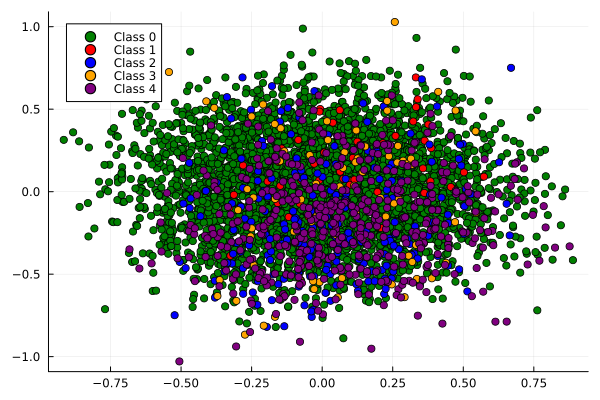

In [31]:
# one hot encoding only for graph
one_hot_train_output = oneHotEncoding(train_output)

colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_3, one_hot_train_output; colors=colors, target_names=target_names)

In [32]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (pca_train_3, train_output),
                                    kFoldIndices)

C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warning

Dict{String, Any} with 8 entries:
  "sensitivity"               => (1.23637, 0.0689228)
  "positive_predictive_value" => (3.7614, 0.268579)
  "specificity"               => (4.16598, 0.0227811)
  "negative_predictive_value" => (4.71453, 0.0608459)
  "f_score"                   => (1.271, 0.0870618)
  "accuracy"                  => (0.837349, 0.0123039)
  "error_rate"                => (0.162651, 0.0123039)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.838856)…

In [33]:
models_accuracies[!, :PCA_3] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_3] = m[3]
    i += 1
end

In [34]:
metrics_pca3 = [
    "PCA_3",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca3)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.938951,0.061049,2.77575,4.73944,4.70045,4.8651,2.96801
2,ZeroMean,0.921754,0.0782459,2.29938,4.70875,4.40703,4.85977,2.3399
3,CrossVal,0.94148,0.0585196,2.60323,4.75702,4.60806,4.91174,2.66209
4,PCA_3,0.837349,0.162651,1.23637,4.16598,3.7614,4.71453,1.271


In [35]:
# Display results
println("METRICS 4th APPROACH (PCA 3 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 3 dimensions):
---------------------
Accuracy: 0.8373487505353194
Error Rate: 0.16265124946468051
Sensitivity (Recall): 1.2363730435119185
Specificity: 4.165975018886954
Precision: 3.761401051914762
Negative Predictive Value: 4.714533060379912
F-Score: 1.271003296989091
----------------------



## 4.b: Reduction at 95% of the representation

In [36]:
## Apply a reduction conserving the 95% of the representation of the data
pca_95 = PCA(0.95)
fit!(pca_95, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_95 = pca_95.transform(train_input_minmax)
pca_test_95 = pca_95.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_95))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_95))

Train Patterns (4648, 13) -> (4648, 11)Train Patterns (1163, 13) -> (1163, 11)

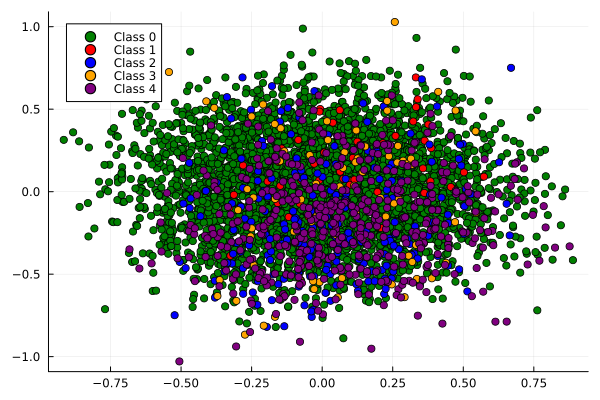

In [37]:
one_hot_train_output = oneHotEncoding(train_output)
colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_95, one_hot_train_output; colors=colors, target_names=target_names)

In [38]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
    (pca_train_95, train_output),
    kFoldIndices)

C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Administrator\.julia\conda\3\x86_64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warning

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.58175, 0.158977)
  "positive_predictive_value" => (4.51702, 0.154163)
  "specificity"               => (4.74215, 0.0423196)
  "negative_predictive_value" => (4.89349, 0.0165768)
  "f_score"                   => (2.65548, 0.238456)
  "accuracy"                  => (0.935886, 0.0040147)
  "error_rate"                => (0.0641145, 0.0040147)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.92943),…

In [39]:
models_accuracies[!, :PCA_095] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_095] = m[3]
    i += 1
end

In [40]:
metrics_pca95 = [
    "PCA_095",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca95)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.938951,0.061049,2.77575,4.73944,4.70045,4.8651,2.96801
2,ZeroMean,0.921754,0.0782459,2.29938,4.70875,4.40703,4.85977,2.3399
3,CrossVal,0.94148,0.0585196,2.60323,4.75702,4.60806,4.91174,2.66209
4,PCA_3,0.837349,0.162651,1.23637,4.16598,3.7614,4.71453,1.271
5,PCA_095,0.935886,0.0641145,2.58175,4.74215,4.51702,4.89349,2.65548


In [41]:
# Display results
println("METRICS 4th APPROACH (PCA 0.95 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 0.95 dimensions):
---------------------
Accuracy: 0.9358855052837483
Error Rate: 0.06411449471625172
Sensitivity (Recall): 2.581747742336144
Specificity: 4.742151639077233
Precision: 4.517018416831596
Negative Predictive Value: 4.893490835842562
F-Score: 2.6554800181212634
----------------------



# Results

In [42]:
println(metrics)

5×8 DataFrame
 Row │ approach  accuracy  error_rate  recall   specificity  ppv      npv      f_score 
     │ String    Float64   Float64     Float64  Float64      Float64  Float64  Float64 
─────┼─────────────────────────────────────────────────────────────────────────────────
   1 │ MinMax    0.938951   0.061049   2.77575      4.73944  4.70045  4.8651   2.96801
   2 │ ZeroMean  0.921754   0.0782459  2.29938      4.70875  4.40703  4.85977  2.3399
   3 │ CrossVal  0.94148    0.0585196  2.60323      4.75702  4.60806  4.91174  2.66209
   4 │ PCA_3     0.837349   0.162651   1.23637      4.16598  3.7614   4.71453  1.271
   5 │ PCA_095   0.935886   0.0641145  2.58175      4.74215  4.51702  4.89349  2.65548


In [43]:
println(models_accuracies)

28×6 DataFrame
 Row │ Model           MinMax    ZeroMean  CrossVal  PCA_3     PCA_095  
     │ String          Float64   Float64   Float64   Float64   Float64  
─────┼──────────────────────────────────────────────────────────────────
   1 │ ANN_64          0.937231  0.907997  0.94234   0.838856  0.92943
   2 │ ANN_128         0.934652  0.919175  0.930722  0.840793  0.92556
   3 │ ANN_64_32       0.938951  0.908856  0.943415  0.840578  0.937608
   4 │ ANN_128_64      0.914015  0.901118  0.938466  0.838856  0.935454
   5 │ ANN_256         0.924334  0.901118  0.940403  0.838211  0.918028
   6 │ ANN_128_64_32   0.936371  0.913156  0.932868  0.832833  0.938898
   7 │ ANN_64_64       0.929493  0.914875  0.926848  0.837134  0.931797
   8 │ ANN_256_128     0.929493  0.914875  0.938681  0.840792  0.936101
   9 │ SVM_rbf_05      0.88908   0.877042  0.885328  0.835198  0.886619
  10 │ SVM_linear_1    0.901118  0.901978  0.904258  0.827453  0.904258
  11 │ SVM_poly_001    0.827171  0.827171  0.827

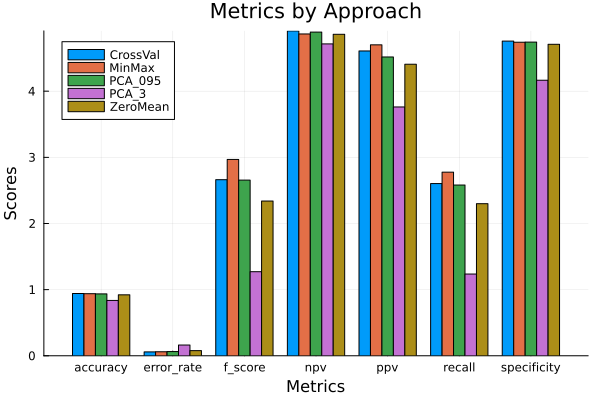

In [44]:
using StatsPlots

df = copy(metrics)

ctg = repeat(["MinMax", "ZeroMean", "CrossVal", "PCA_3", "PCA_095"], inner=7)
nam = repeat(names(df)[2:8], outer=5)
mm = collect(df[1,2:8])
zm = collect(df[2,2:8])
cv = collect(df[3,2:8])
pca3 = collect(df[4,2:8])
pca95 = collect(df[5,2:8])

groupedbar(nam, [mm zm cv pca3 pca95], group = ctg, xlabel = "Metrics", ylabel = "Scores",
           title = "Metrics by Approach")

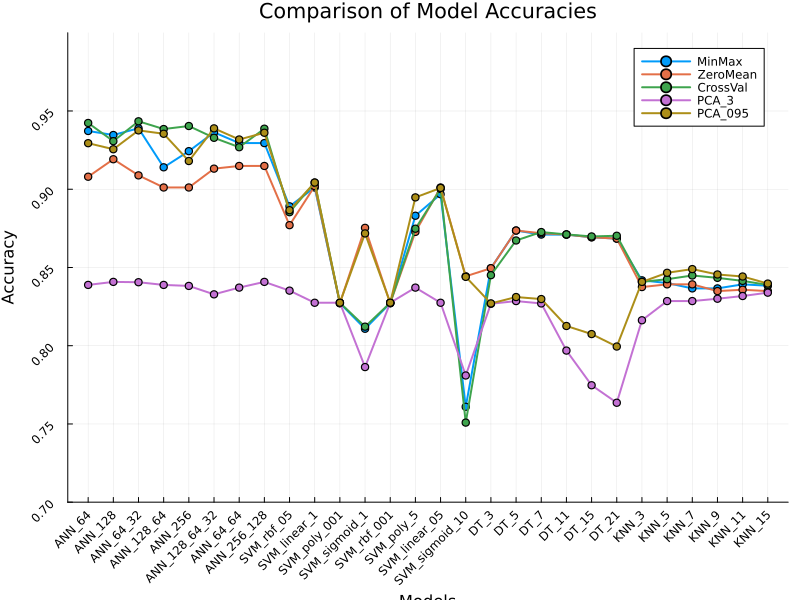

In [45]:
using Plots

df = copy(models_accuracies)

p = plot(
    1:nrow(df), 
    Matrix(df[:, 2:end]),
    label = permutedims(names(df)[2:end]),
    title = "Comparison of Model Accuracies",
    xlabel = "Models",
    ylabel = "Accuracy",
    legend = :topright,
    size = (800, 600),
    lw = 2,
    marker = :circle,
    markersize = 4
)
xticks!(1:nrow(df), df.Model, rotation = 45)
ylims!(0.7, 1.0)